# Estimate code-capacity logical error rates

The code-capacity model isolates the code and decoder from circuit faults.
Physical bits or qubits are corrupted independently, while state preparation, syndrome measurement, and correction are treated as perfect.
The benchmark asks how often decoding changes the logical state: how often the decoder's proposed correction combines with the sampled error to form a logical operator, or, for a decoder that predicts logical effects directly, how often it mispredicts which logical operators the sampled error flips.

For a length-$n$ code at physical error rate $p$, the number of corrupted positions (meaning bits or qubits) follows a binomial distribution.
qLDPC samples errors by weight, estimates the decoder's failure probability at each sampled weight, and combines those estimates using the binomial probabilities.
Changing $p$ changes only that final weighting, so one set of decoder samples can estimate a sweep of physical error rates.


## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.


In [1]:
%%capture
%pip install qldpc matplotlib

In [2]:
from collections.abc import Sequence
from itertools import cycle

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from sympy.abc import x, y

from qldpc import codes, decoders

## One reusable workflow

`get_logical_error_rate_func` samples decoding outcomes and returns a callable estimator.
Evaluating that estimator at one or more physical error rates returns the estimated logical rates and their statistical standard deviations.

The finite sample budget covers only part of the error-weight distribution.
Heavier unsampled errors are conservatively counted as failures, and `truncation_error_bound` reports how much that assumption can raise the estimate.
The shaded band combines one statistical standard deviation with this one-sided truncation bound; it is a diagnostic guide, not an exact confidence interval.


In [3]:
def code_label(code: codes.AbstractCode) -> str:
    """Return a compact code-parameter label for a plot legend."""
    known_distance = code.get_distance_if_known()
    brackets = ("[", "]") if isinstance(code, codes.ClassicalCode) else ("[[", "]]")
    entries = [len(code), code.dimension]
    if known_distance is not None:
        entries.append(known_distance)
    return brackets[0] + ", ".join(map(str, entries)) + brackets[1]


def make_code_capacity_figure(
    codes_to_plot: Sequence[codes.ClassicalCode | codes.QuditCode],
    *,
    error_rates: Sequence[float] = tuple(np.logspace(-2, -0.1, 60)),
    num_samples: int = 10_000,
    figsize: tuple[float, float] = (5.5, 4.2),
    decoder: decoders.DecoderInput = None,
) -> tuple[Figure, Axes]:
    """Plot estimated code-capacity logical error rates for the requested codes."""
    figure, axis = plt.subplots(figsize=figsize)
    styles = cycle(("o-", "s--", "^-.", "D:"))

    for code_to_plot, style in zip(codes_to_plot, styles):
        estimator = code_to_plot.get_logical_error_rate_func(
            num_samples=num_samples,
            max_error_rate=max(error_rates),
            decoder=decoder,
        )
        logical_rates, statistical_error = estimator(error_rates)
        truncation = estimator.truncation_error_bound(error_rates)

        line, *_ = axis.plot(
            error_rates,
            logical_rates,
            style,
            markevery=8,
            label=code_label(code_to_plot),
        )
        axis.fill_between(
            error_rates,
            np.maximum(logical_rates - statistical_error - truncation, 0),
            logical_rates + statistical_error,
            color=line.get_color(),
            alpha=0.18,
        )

    reference_rates = [min(error_rates), max(error_rates)]
    axis.plot(
        reference_rates,
        reference_rates,
        color="black",
        linestyle=":",
        label=r"$p_{\mathrm{logical}}=p_{\mathrm{physical}}$",
    )
    axis.loglog()
    axis.set_xlim(right=1)
    axis.set_ylim(bottom=max(min(error_rates) ** 2, axis.get_ylim()[0]), top=1)
    axis.set_xlabel("physical error rate")
    axis.set_ylabel("estimated logical error rate")
    axis.legend(loc="best")
    axis.grid(which="both", alpha=0.3)
    figure.tight_layout()
    return figure, axis

## Repetition codes

For a repetition code, decoding reduces to a one-dimensional matching problem that minimum-weight perfect matching (MWPM) solves exactly.
At low physical error rates, increasing the code distance suppressses logical failures.
The finite sample budget limits how far down the plot that suppression can be resolved.


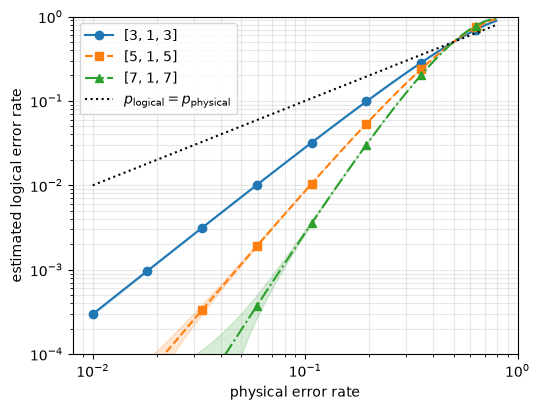

In [4]:
repetition_codes = [codes.RepetitionCode(distance) for distance in (3, 5, 7)]
make_code_capacity_figure(repetition_codes, decoder=decoders.mwpm())
plt.show()

The curves separate over the sampled range, while the shaded regions widen where the samples contain little information about the relevant error weights.


## Surface codes

The same workflow accepts quantum CSS codes.
With no Pauli bias supplied, each erroneous qubit receives X, Y, or Z with equal probability.


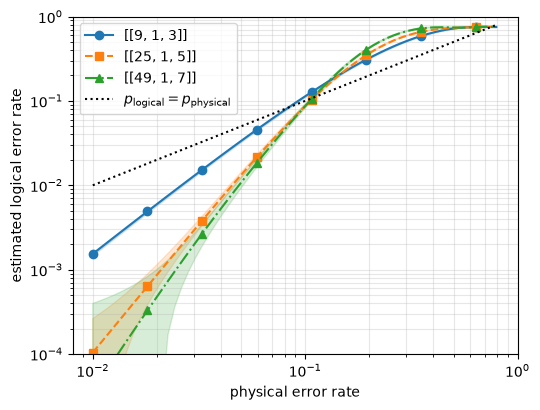

In [5]:
surface_codes = [codes.SurfaceCode(distance) for distance in (3, 5, 7)]
make_code_capacity_figure(surface_codes, decoder=decoders.mwpm())
plt.show()

## Bivariate bicycle codes

For this small comparison, BP+LSD replaces MWPM because the bivariate-bicycle checks do not produce a simple matching graph.
The code labels omit distance when qLDPC does not already know an exact value.


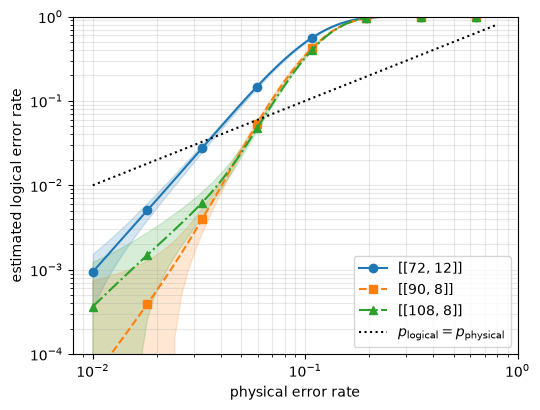

In [6]:
bb_codes = [
    codes.BBCode({x: 6, y: 6}, x**3 + y + y**2, y**3 + x + x**2),
    codes.BBCode({x: 15, y: 3}, x**9 + y + y**2, 1 + x**2 + x**7),
    codes.BBCode({x: 9, y: 6}, x**3 + y + y**2, y**3 + x + x**2),
]
make_code_capacity_figure(bb_codes, decoder=decoders.bp_lsd())
plt.show()

## Error decoders and observable decoders

A code-capacity estimate only needs to know whether decoding changed the logical state.
qLDPC therefore decodes each sampled syndrome with an *observable decoder*, which predicts the logical operators that the sampled error flips, and counts a failure whenever that prediction is wrong.

The `decoder=` arguments of a code-capacity estimate accept either kind of decoder:

- An *error decoder*, such as `decoders.lookup(...)` or `decoders.mwpm()` above, infers a physical error, and the logical operators flipped by that error are its prediction.
- A Sinter-style decoder, such as `decoders.SinterDecoder(decoder=decoders.lookup(...))`, is compiled for a code-capacity detector error model, and predicts logical flips directly when its settings support it (as `lookup`, `mwpm`, and `relay_bp` do).
  A prebuilt observable decoder, such as an `ObservableLookupDecoder`, also predicts logical flips directly.

The most likely logical class of an error need not contain the most likely individual error.
Degenerate codes, in which many low-weight errors share a syndrome, make the difference visible.
Below, the same lookup table decodes a distance-4 surface code both ways: as an error decoder, it chooses the lowest-weight error consistent with each syndrome, whereas as an observable decoder, it chooses the logical class with the largest total probability among the errors in its table.

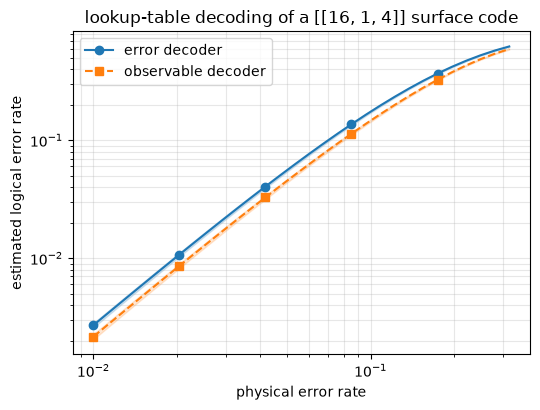

In [7]:
surface_code = codes.SurfaceCode(4)
error_rates = np.logspace(-2, -0.5, 30)
lookup_settings = decoders.lookup(max_weight=3)

figure, axis = plt.subplots(figsize=(5.5, 4.2))
for label, style, decoder in [
    ("error decoder", "o-", lookup_settings),
    ("observable decoder", "s--", decoders.SinterDecoder(decoder=lookup_settings)),
]:
    estimator = surface_code.get_logical_error_rate_func(
        num_samples=10_000,
        max_error_rate=max(error_rates),
        decoder=decoder,
    )
    logical_rates, statistical_error = estimator(error_rates)
    truncation = estimator.truncation_error_bound(error_rates)
    line, *_ = axis.plot(error_rates, logical_rates, style, markevery=6, label=label)
    axis.fill_between(
        error_rates,
        np.maximum(logical_rates - statistical_error - truncation, 0),
        logical_rates + statistical_error,
        color=line.get_color(),
        alpha=0.18,
    )

axis.loglog()
axis.set_title(f"lookup-table decoding of a {code_label(surface_code)} surface code")
axis.set_xlabel("physical error rate")
axis.set_ylabel("estimated logical error rate")
axis.legend(loc="best")
axis.grid(which="both", alpha=0.3)
figure.tight_layout()
plt.show()

Predicting logical classes directly lowers the logical error rate of this degenerate code.

For a CSS code, `decoder_x=` and `decoder_z=` configure the two sectors separately, and each may receive either kind of decoder.
Sinter-style decoders compile for binary Stim detector error models, so a nonbinary code needs error-decoder settings or a prebuilt observable decoder built for its field.